In [17]:
import matplotlib.pyplot as plt
from pathlib import Path

from config import BENCHMARKS
from utils import plot_pool_distribution

BENCHMARK = "DRIFT_SWEEP"
BENCH_PARAMS = BENCHMARKS[BENCHMARK]
THRESHOLD = BENCH_PARAMS["threshold"]
SAMPLE_SIZE = BENCH_PARAMS["sample_size"]
SPARSITY_MIN = BENCH_PARAMS["sparsity_min"]
MIN_DRIFT_DAYS = BENCH_PARAMS["min_drift_days"]
PERSIST_SWEEP = BENCH_PARAMS["persistence_sweep_days"]

SUSTAINED_COL = f"S_p{MIN_DRIFT_DAYS}"
SUSTAINED_XLABEL = f"Max {MIN_DRIFT_DAYS}-day-sustained relative deviation"

SOURCES = [
    ("institutions", "Institutions"),
    ("subnets", "Subnets"),
    ("ips_full", "IPs"),
]

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 15,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

GRAPH_DIR = Path('sensitivity_analysis/figures')
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

print(f"Benchmark: {BENCHMARK} | threshold rel_dev > {THRESHOLD}, persistence >= {MIN_DRIFT_DAYS}d | sparsity >= {SPARSITY_MIN} | sample size {SAMPLE_SIZE}")

Benchmark: DRIFT_SWEEP | threshold rel_dev > 0.3, persistence >= 14d | sparsity >= 0.9 | sample size 25


In [18]:
from sensitivity_analysis.drift_utils import (
    load_sweep,
    sweep_dev,
    sweep_persist,
    plot_drift_sweep,
    plot_sp_survival,
    calendar_week_analysis,
)

## Hourly

In [19]:
print("Loading hourly scores:")
sweep_dfs_hourly = load_sweep("hourly", SOURCES)

Loading hourly scores:
  Institutions: 276/283 pass sparsity >= 0.9
  Subnets: 507/548 pass sparsity >= 0.9
  IPs: 21451/275124 pass sparsity >= 0.9


### 1. Distribution of Max 14-Day-Sustained Deviation

For each series $y$, define
$$
S_p(y) \;:=\; \max_{t} \; \min_{s \in [t-p+1,\,t]} r_s,
$$
where $r_s = \bigl|\bar y_s^{\mathrm{short}} - \bar y_s^{\mathrm{long}}\bigr| \,/\, \bar y_s^{\mathrm{long}}$ is the relative deviation between the $168$-hour and $744$-hour rolling means. $S_p$ is the largest amplitude the series sustains over any contiguous $p$-day window in its timeline; equivalently, $S_p(y) \ge \tau \iff \texttt{has\_drift}(y, \tau, p)$. With $\tau = 0.30$ and $p = 14\,\mathrm{d}$, bars to the right of the threshold form the $\texttt{has\_drift}$ population; the benchmark's qualifying pool is the subset that additionally satisfies $\texttt{drift\_in\_test}$ (next panel).

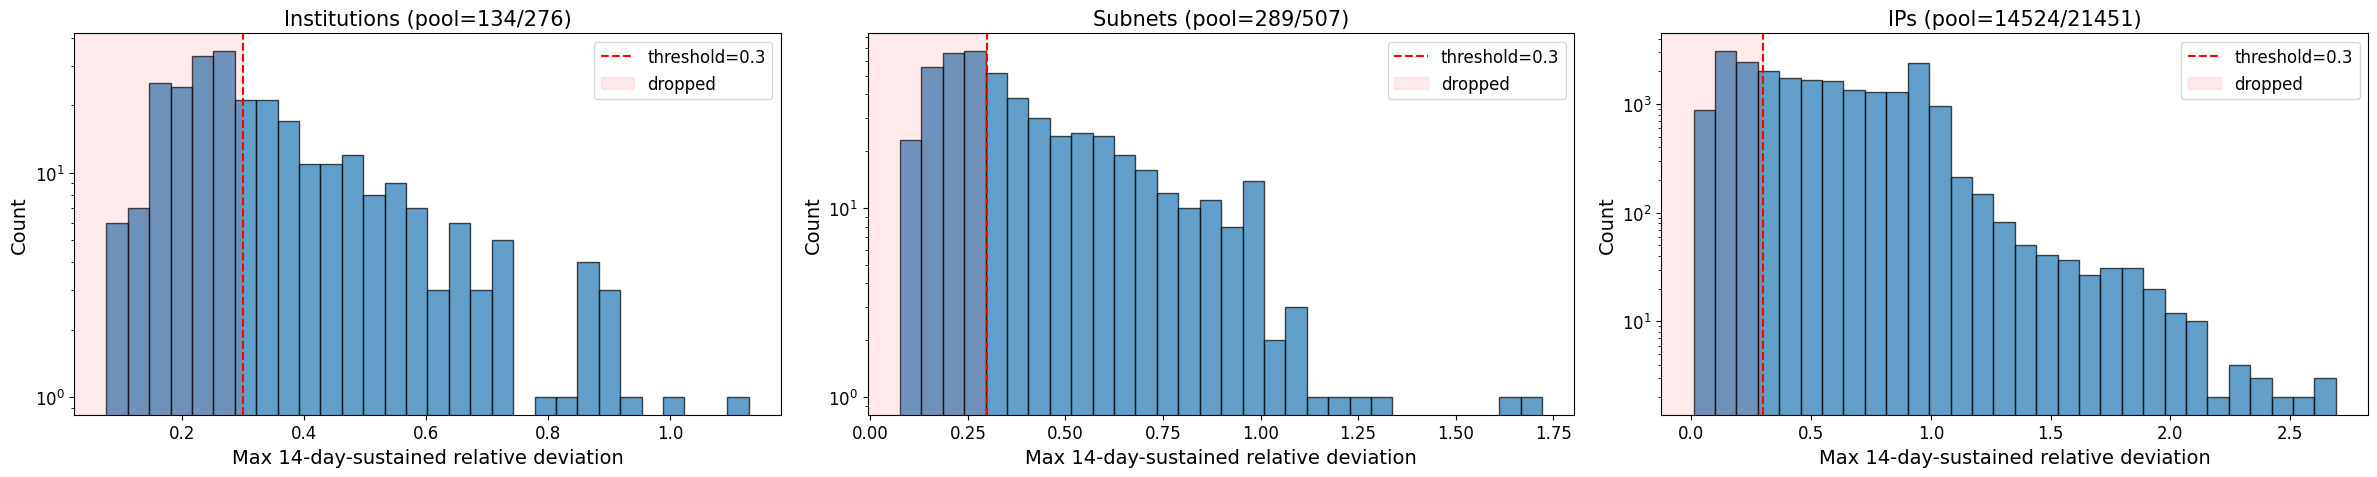

In [20]:
plot_pool_distribution(
    [(sweep_dfs_hourly[label], label) for _, label in SOURCES],
    metric_col=SUSTAINED_COL,
    threshold=THRESHOLD,
    xlabel=SUSTAINED_XLABEL,
    log_y=True,
    save_path=GRAPH_DIR / "DRIFT_sustained_dev_hist_hourly.pdf",
)

Restricting the outer maximum to $t \ge t_{\mathrm{test}}$ yields
$$
S_p^{\,\mathrm{test}}(y) \;:=\; \max_{t \ge t_{\mathrm{test}}} \; \min_{s \in [t-p+1,\,t]} r_s,
$$
the scalar against which the benchmark's qualifying rule is exact: $S_p^{\,\mathrm{test}}(y) \ge \tau \iff \texttt{drift\_in\_test}(y, \tau, p)$. Bars to the right of the threshold are precisely the qualifying pool from which the benchmark samples.

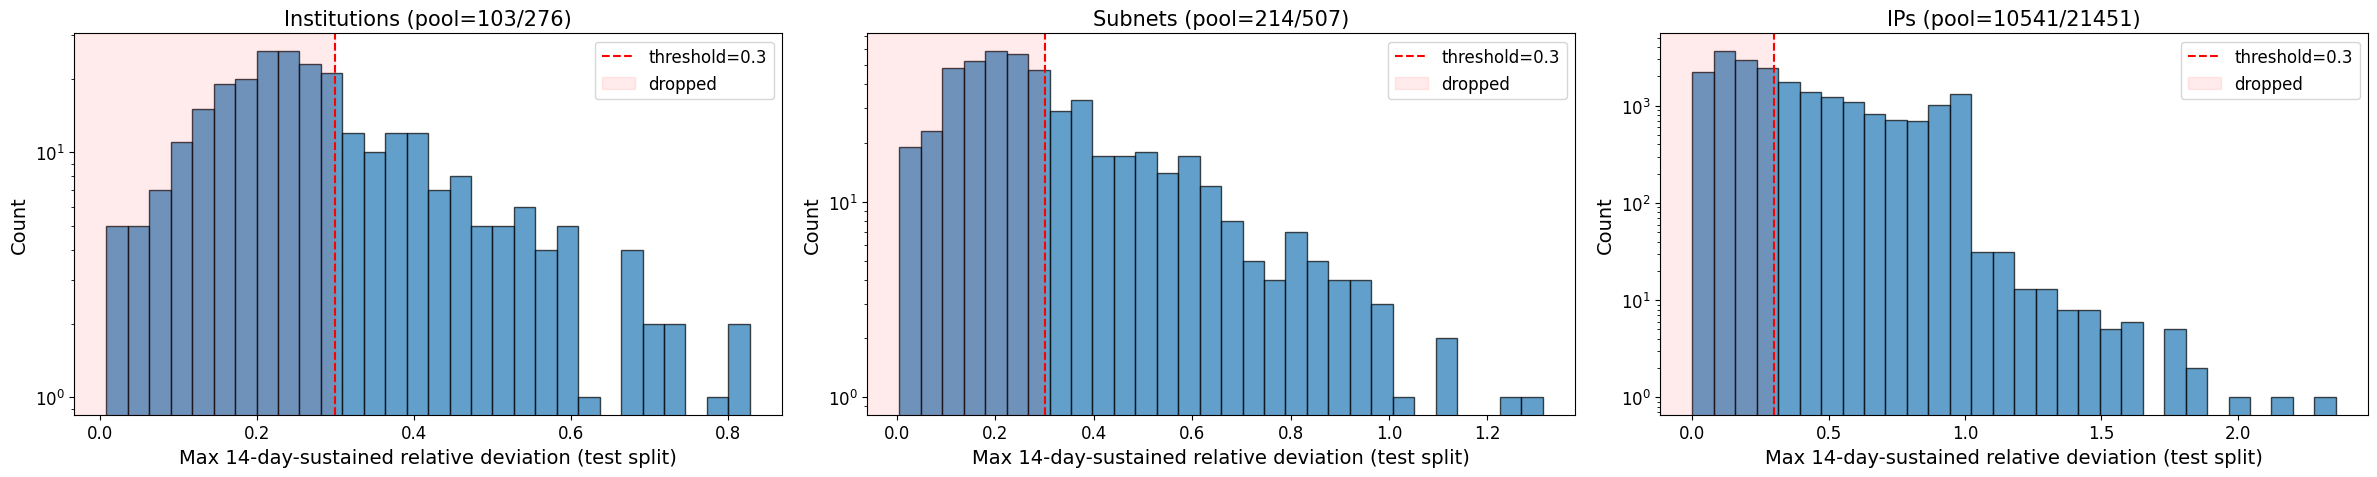

In [21]:
plot_pool_distribution(
    [(sweep_dfs_hourly[label], label) for _, label in SOURCES],
    metric_col=f"S_p{MIN_DRIFT_DAYS}_test",
    threshold=THRESHOLD,
    xlabel=f"Max {MIN_DRIFT_DAYS}-day-sustained relative deviation (test split)",
    log_y=True,
    save_path=GRAPH_DIR / "DRIFT_sustained_dev_test_hist_hourly.pdf",
)

### 1c. Persistence sensitivity: survival curves of $S_p$

For each $p \in \{7, 14, 21, 28\}$ days, the empirical survival function $\Pr[S_p \ge \tau]$ reports the fraction of the post-sparsity population that qualifies under amplitude threshold $\tau$. The vertical line marks the chosen $\tau = 0.30$; the vertical gap between curves at this line is the persistence sensitivity in distribution form, equivalent to the count differences in §3 below.

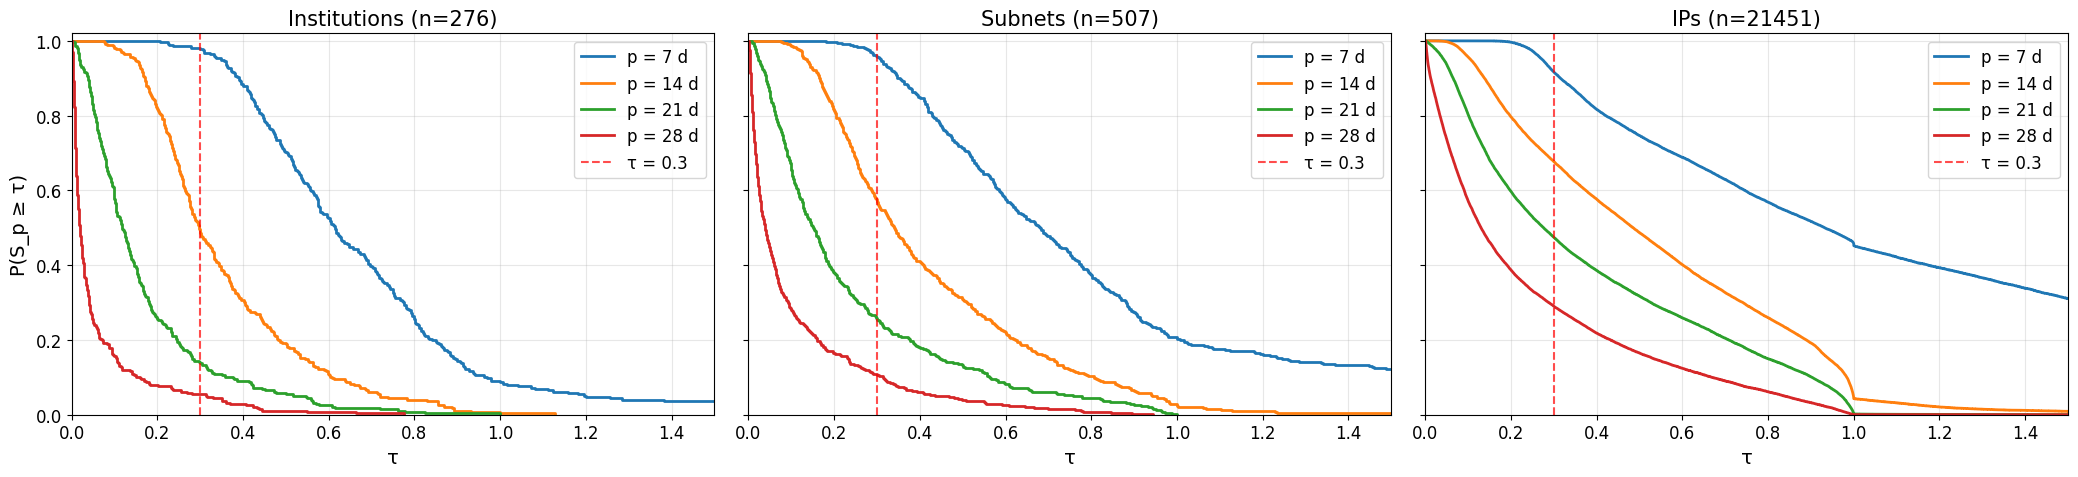

In [22]:
plot_sp_survival(
    sweep_dfs_hourly,
    persistence_days=PERSIST_SWEEP,
    threshold=THRESHOLD,
    save_path=GRAPH_DIR / "DRIFT_persistence_survival_hourly.pdf",
)

### 2. Deviation Threshold Sweep (persistence = 14 days)

,threshold,Institutions pool,Institutions events,Subnets pool,Subnets events,IPs pool,IPs events
0,0.10,257,893,463,1633,18218,73243
1,0.15,230,624,398,1160,15926,58307
2,0.20,193,419,338,840,13908,47602
3,0.25,144,272,268,590,12107,39269
4,0.30,103,187,214,454,10541,32815
5,0.35,80,123,176,356,9297,27851
6,0.40,62,91,139,275,8283,23720
7,0.45,43,61,117,225,7396,20282
8,0.50,32,41,100,184,6546,17478
9,0.55,23,28,83,149,5800,15008


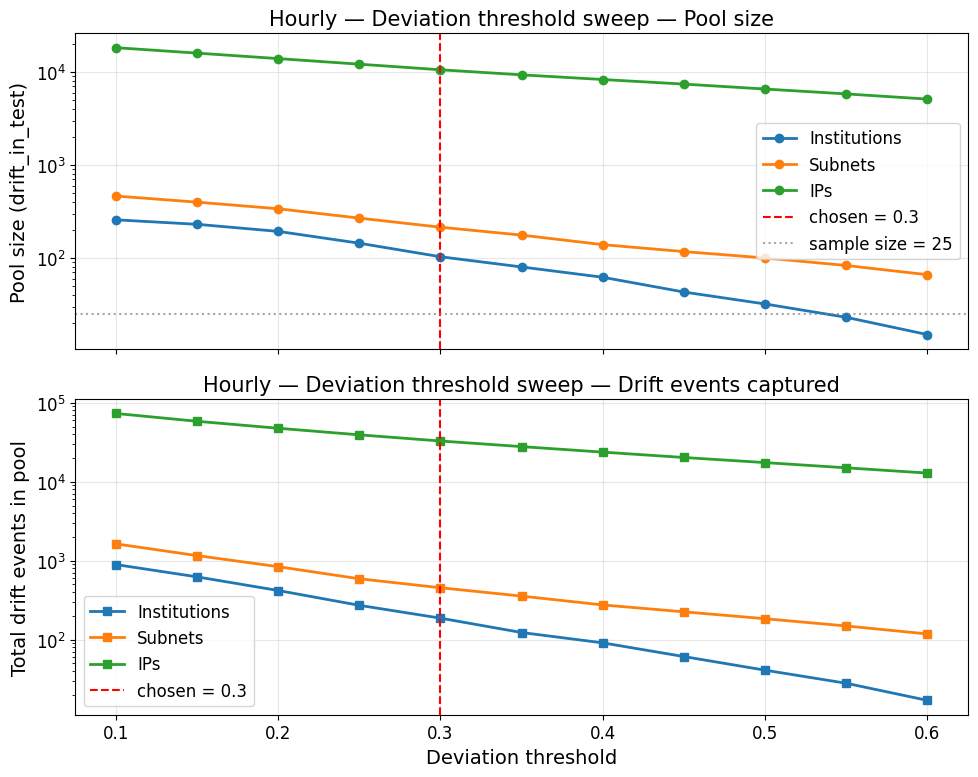

In [23]:
sweep_dev_hourly = sweep_dev(sweep_dfs_hourly, MIN_DRIFT_DAYS)
display(sweep_dev_hourly)
plot_drift_sweep(sweep_dev_hourly, "threshold", "Hourly — Deviation threshold sweep", THRESHOLD,
                 SAMPLE_SIZE, "Deviation threshold",
                 save_path=GRAPH_DIR / "DRIFT_dev_sweep_hourly.pdf")

### 3. Persistence Sweep (deviation = 0.30)

,persistence_days,Institutions pool,Institutions events,Subnets pool,Subnets events,IPs pool,IPs events
0,7,255,922,441,1847,17465,100038
1,14,103,187,214,454,10541,32815
2,21,18,23,70,126,5591,13771
3,28,9,9,33,46,3131,6081


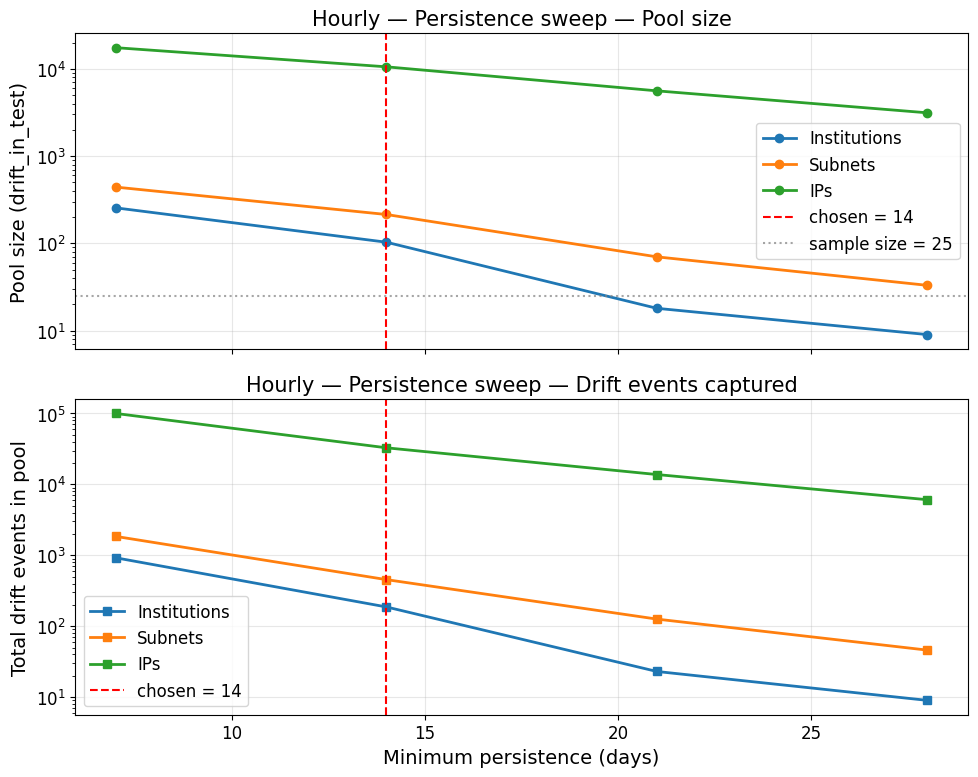

In [24]:
sweep_pers_hourly = sweep_persist(sweep_dfs_hourly, THRESHOLD)
display(sweep_pers_hourly)
plot_drift_sweep(sweep_pers_hourly, "persistence_days", "Hourly — Persistence sweep", MIN_DRIFT_DAYS,
                 SAMPLE_SIZE, "Minimum persistence (days)",
                 save_path=GRAPH_DIR / "DRIFT_persistence_sweep_hourly.pdf")

### 4. Calendar-Week Diversity Check

  Institutions: 25 selected (from selected_ids/hourly/DRIFT.csv) — loading their data...


100%|███████████████████████████████████| 25/25 [00:08<00:00,  3.04it/s]


Config Details
    Used for database: CESNET-TimeSeries24
    Aggregation: AgreggationType.AGG_1_HOUR
    Source: SourceType.INSTITUTIONS

    Time series
        Time series IDS: [ 4  9 20 26 56 ... 213 238 251 261 269], Length=25
    Time periods
        Train time periods: range(0, 6718)
        Val time periods: None
        Test time periods: None
        All time periods: range(0, 6718)
    Features
        Taken features: ['n_bytes']
        Default values: [0.]
        Time series ID included: True
        Time included: True    
        Time format: TimeFormat.DATETIME
    Sliding window
        Sliding window size: None
        Sliding window prediction size: None
        Sliding window step size: 1
        Set shared size: 0
    Fillers
        Filler type: NoFiller
    Transformers
        Transformer type: NoTransformer
    Anomaly handler
        Anomaly handler type: NoAnomalyHandler        
    Batch sizes
        Train batch size: 32
        Val batch size: 64
       

institutions (AGG_1_HOUR): 25 series loaded
  Subnets: 25 selected (from selected_ids/hourly/DRIFT.csv) — loading their data...


100%|███████████████████████████████████| 25/25 [00:07<00:00,  3.19it/s]


Config Details
    Used for database: CESNET-TimeSeries24
    Aggregation: AgreggationType.AGG_1_HOUR
    Source: SourceType.INSTITUTION_SUBNETS

    Time series
        Time series IDS: [ 26  43  48  96 133 ... 477 498 501 523 533], Length=25
    Time periods
        Train time periods: range(0, 6718)
        Val time periods: None
        Test time periods: None
        All time periods: range(0, 6718)
    Features
        Taken features: ['n_bytes']
        Default values: [0.]
        Time series ID included: True
        Time included: True    
        Time format: TimeFormat.DATETIME
    Sliding window
        Sliding window size: None
        Sliding window prediction size: None
        Sliding window step size: 1
        Set shared size: 0
    Fillers
        Filler type: NoFiller
    Transformers
        Transformer type: NoTransformer
    Anomaly handler
        Anomaly handler type: NoAnomalyHandler        
    Batch sizes
        Train batch size: 32
        Val batch size

subnets (AGG_1_HOUR): 25 series loaded
  IPs: 25 selected (from selected_ids/hourly/DRIFT.csv) — loading their data...


100%|███████████████████████████████████| 25/25 [00:07<00:00,  3.30it/s]


Config Details
    Used for database: CESNET-TimeSeries24
    Aggregation: AgreggationType.AGG_1_HOUR
    Source: SourceType.IP_ADDRESSES_FULL

    Time series
        Time series IDS: [1367 1368 1605 1774 3271 ... 565727 617662 745827 756220 783215], Length=25
    Time periods
        Train time periods: range(0, 6718)
        Val time periods: None
        Test time periods: None
        All time periods: range(0, 6718)
    Features
        Taken features: ['n_bytes']
        Default values: [0.]
        Time series ID included: True
        Time included: True    
        Time format: TimeFormat.DATETIME
    Sliding window
        Sliding window size: None
        Sliding window prediction size: None
        Sliding window step size: 1
        Set shared size: 0
    Fillers
        Filler type: NoFiller
    Transformers
        Transformer type: NoTransformer
    Anomaly handler
        Anomaly handler type: NoAnomalyHandler        
    Batch sizes
        Train batch size: 32
    

ips_full (AGG_1_HOUR): 25 series loaded

  Total drift events across selected series: 166
  Distinct series with >=1 event: 74
  Distinct calendar weeks with >=1 event: 33
  Date range: 2023-11-22 to 2024-07-12 (35 weeks span)


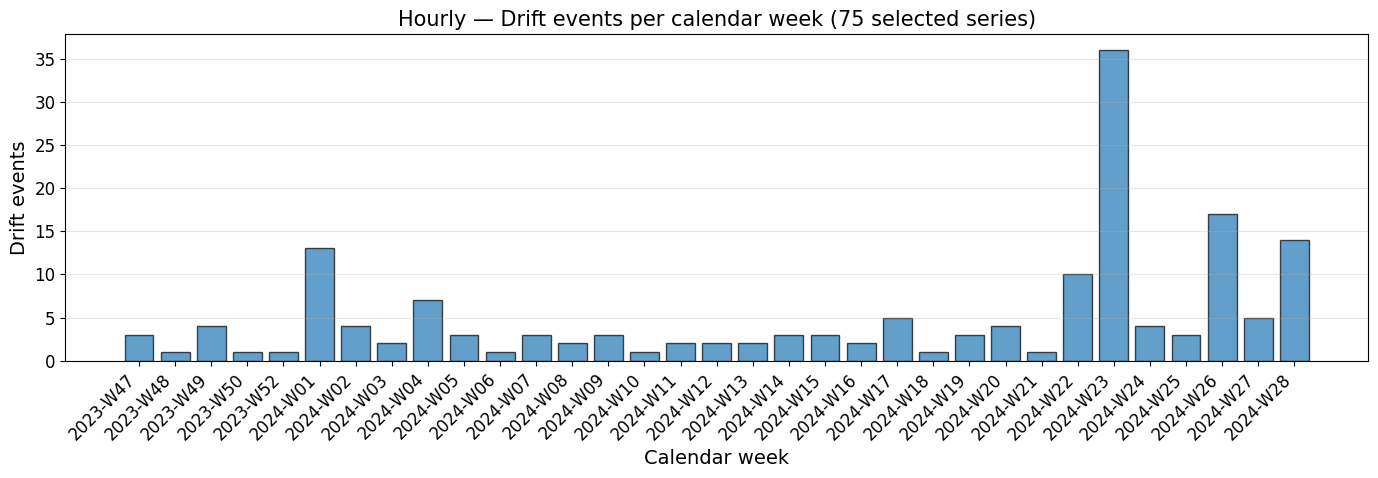


  Events per level:
    Institutions: 39 events across 12 distinct weeks
    Subnets: 45 events across 17 distinct weeks
    IPs: 82 events across 30 distinct weeks


In [25]:
events_hourly = calendar_week_analysis(SOURCES, "hourly",
                                       save_path=GRAPH_DIR / "DRIFT_calendar_weeks_hourly.pdf")

## 10-Minute

In [26]:
print("Loading 10-minute scores:")
sweep_dfs_10min = load_sweep("10min", SOURCES)

Loading 10-minute scores:
  Institutions: 235/283 pass sparsity >= 0.9
  Subnets: 373/548 pass sparsity >= 0.9
  IPs: 7353/275124 pass sparsity >= 0.9


### 1. Distribution of Max 14-Day-Sustained Deviation

The whole-series scalar $S_p$ at the $10$-minute resolution: $p = 14\,\mathrm{d}$ corresponds to $2016$ steps, with the short and long rolling means scaled to $1008$ and $4464$ steps respectively. The threshold cut and the equivalence $S_p \ge \tau \iff \texttt{has\_drift}$ are as defined in the hourly section above.

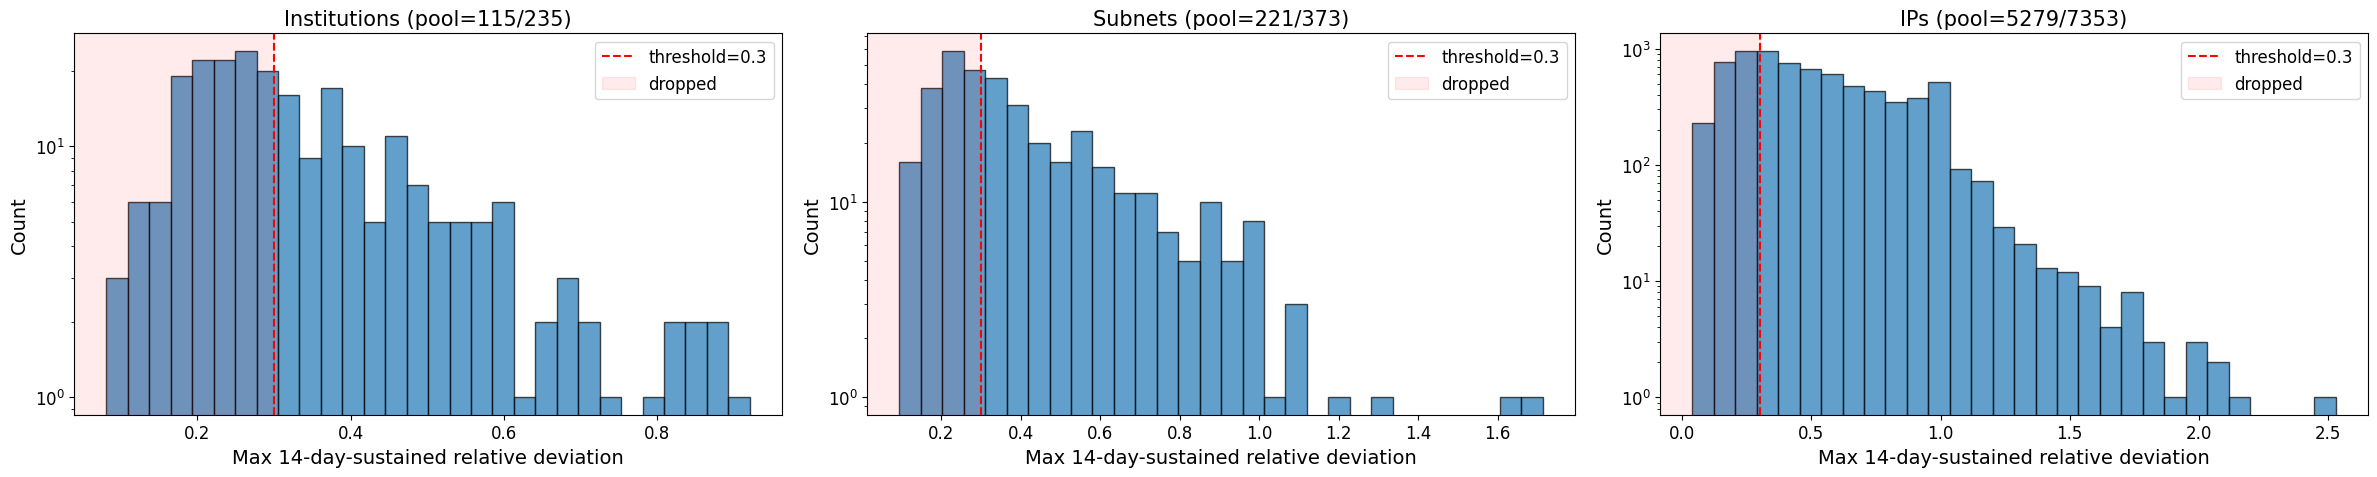

In [27]:
plot_pool_distribution(
    [(sweep_dfs_10min[label], label) for _, label in SOURCES],
    metric_col=SUSTAINED_COL,
    threshold=THRESHOLD,
    xlabel=SUSTAINED_XLABEL,
    log_y=True,
    save_path=GRAPH_DIR / "DRIFT_sustained_dev_hist_10min.pdf",
)

The test-restricted scalar $S_p^{\,\mathrm{test}}$ at the $10$-minute resolution. Bars to the right of the threshold are precisely the qualifying pool sampled by the benchmark.

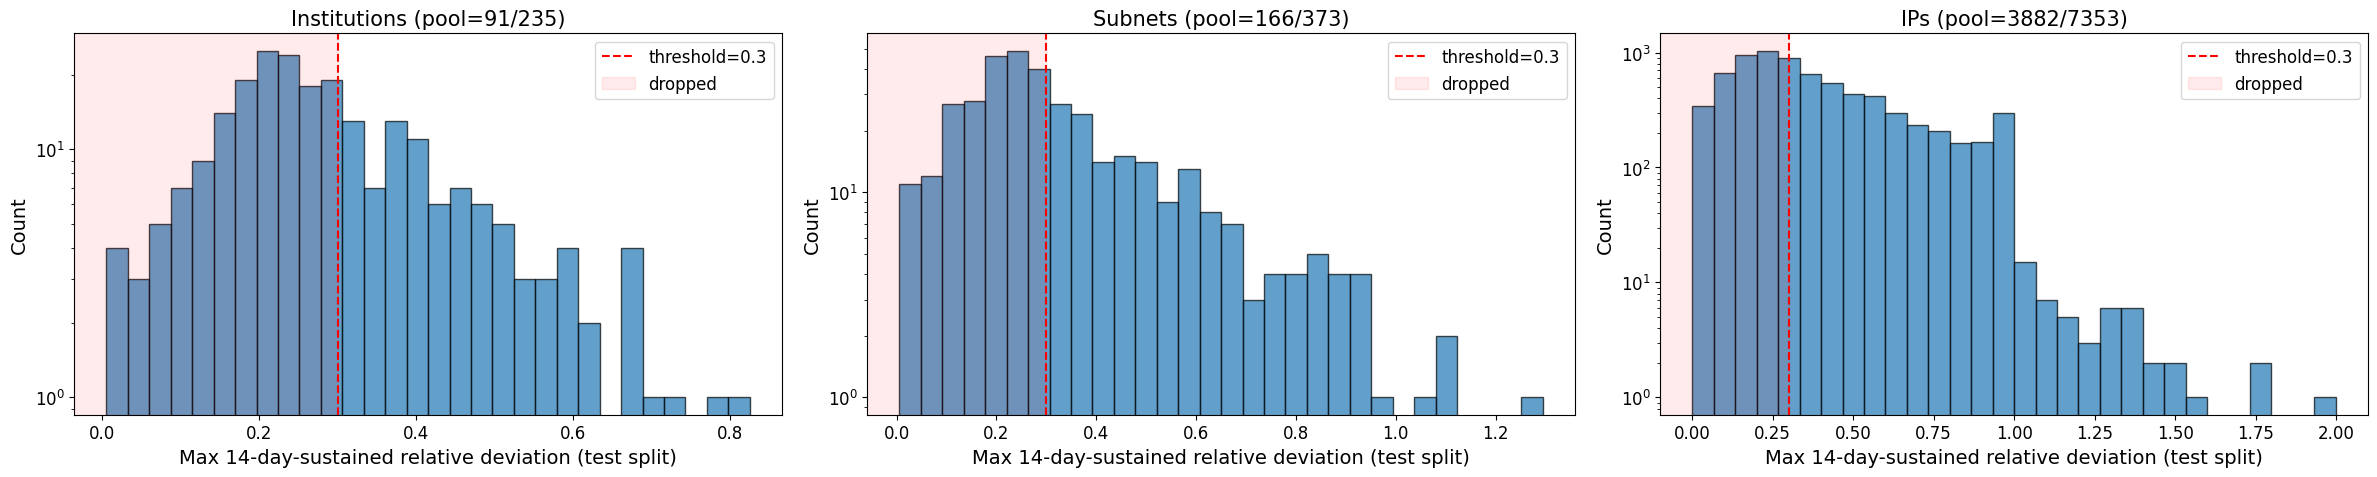

In [28]:
plot_pool_distribution(
    [(sweep_dfs_10min[label], label) for _, label in SOURCES],
    metric_col=f"S_p{MIN_DRIFT_DAYS}_test",
    threshold=THRESHOLD,
    xlabel=f"Max {MIN_DRIFT_DAYS}-day-sustained relative deviation (test split)",
    log_y=True,
    save_path=GRAPH_DIR / "DRIFT_sustained_dev_test_hist_10min.pdf",
)

### 1c. Persistence sensitivity: survival curves of $S_p$

The same view at the 10-minute resolution; window lengths $p \in \{7, 14, 21, 28\}$ days correspond to step counts $\{1008, 2016, 3024, 4032\}$.

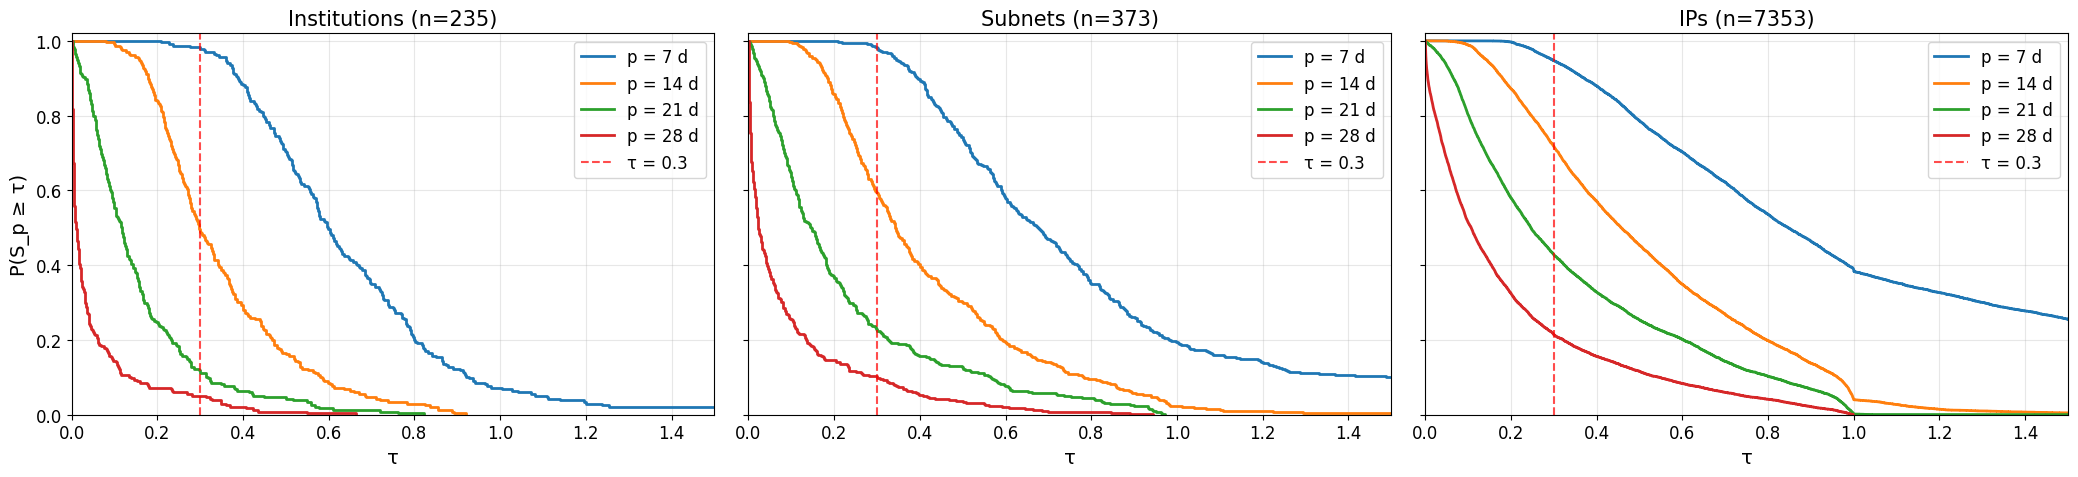

In [29]:
plot_sp_survival(
    sweep_dfs_10min,
    persistence_days=PERSIST_SWEEP,
    threshold=THRESHOLD,
    save_path=GRAPH_DIR / "DRIFT_persistence_survival_10min.pdf",
)

### 2. Deviation Threshold Sweep (persistence = 14 days)

,threshold,Institutions pool,Institutions events,Subnets pool,Subnets events,IPs pool,IPs events
0,0.10,221,754,347,1232,6697,25539
1,0.15,201,524,313,888,6115,20144
2,0.20,172,369,272,673,5396,16161
3,0.25,127,241,213,458,4602,12930
4,0.30,91,155,166,335,3882,10426
5,0.35,70,105,133,261,3274,8568
6,0.40,52,77,105,203,2810,7162
7,0.45,35,49,85,164,2389,5907
8,0.50,25,33,73,134,2042,4995
9,0.55,17,20,59,107,1724,4143


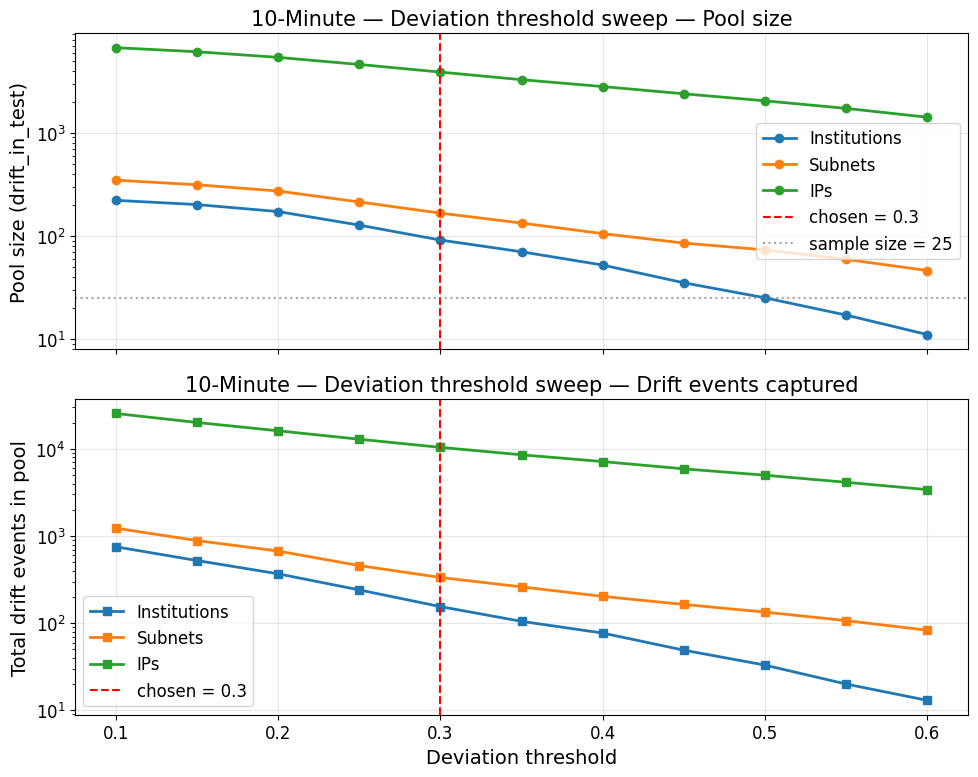

In [30]:
sweep_dev_10min = sweep_dev(sweep_dfs_10min, MIN_DRIFT_DAYS)
display(sweep_dev_10min)
plot_drift_sweep(sweep_dev_10min, "threshold", "10-Minute — Deviation threshold sweep", THRESHOLD,
                 SAMPLE_SIZE, "Deviation threshold",
                 save_path=GRAPH_DIR / "DRIFT_dev_sweep_10min.pdf")

### 3. Persistence Sweep (deviation = 0.30)

,persistence_days,Institutions pool,Institutions events,Subnets pool,Subnets events,IPs pool,IPs events
0,7,219,746,349,1408,6504,33094
1,14,91,155,166,335,3882,10426
2,21,13,17,47,87,1674,3855
3,28,7,7,22,31,772,1400


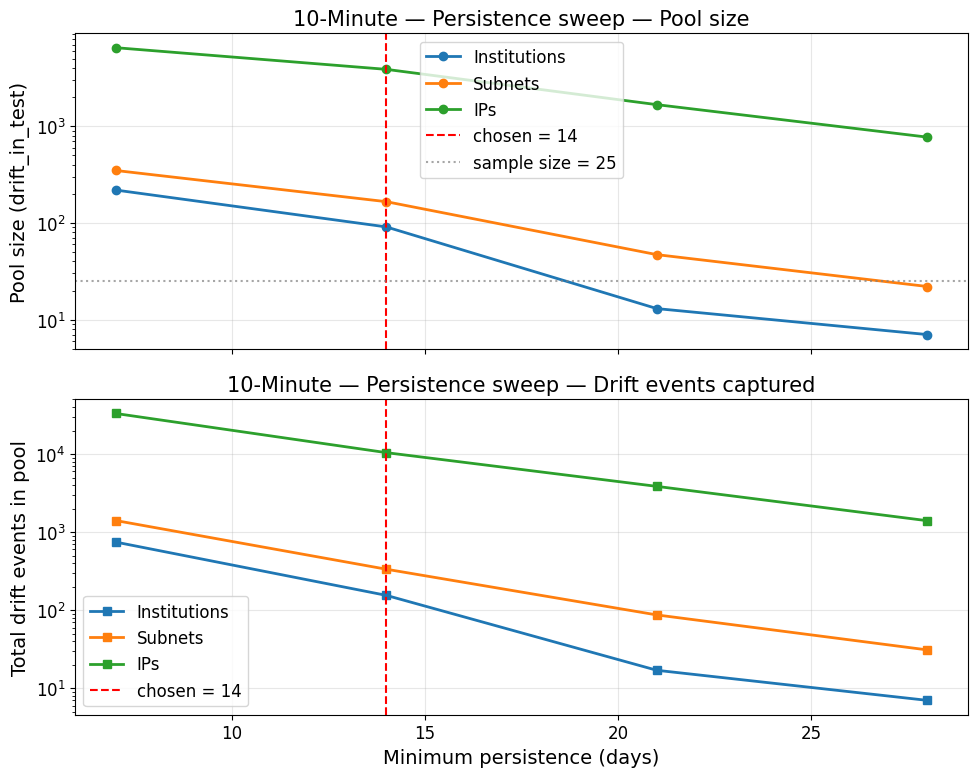

In [31]:
sweep_pers_10min = sweep_persist(sweep_dfs_10min, THRESHOLD)
display(sweep_pers_10min)
plot_drift_sweep(sweep_pers_10min, "persistence_days", "10-Minute — Persistence sweep", MIN_DRIFT_DAYS,
                 SAMPLE_SIZE, "Minimum persistence (days)",
                 save_path=GRAPH_DIR / "DRIFT_persistence_sweep_10min.pdf")

### 4. Calendar-Week Diversity Check

  Institutions: 25 selected (from selected_ids/10min/DRIFT.csv) — loading their data...


100%|███████████████████████████████████| 25/25 [00:07<00:00,  3.18it/s]



Config Details
    Used for database: CESNET-TimeSeries24
    Aggregation: AgreggationType.AGG_10_MINUTES
    Source: SourceType.INSTITUTIONS

    Time series
        Time series IDS: [ 4 11 26 38 53 ... 202 211 231 254 259], Length=25
    Time periods
        Train time periods: range(0, 40298)
        Val time periods: None
        Test time periods: None
        All time periods: range(0, 40298)
    Features
        Taken features: ['n_bytes']
        Default values: [0.]
        Time series ID included: True
        Time included: True    
        Time format: TimeFormat.DATETIME
    Sliding window
        Sliding window size: None
        Sliding window prediction size: None
        Sliding window step size: 1
        Set shared size: 0
    Fillers
        Filler type: NoFiller
    Transformers
        Transformer type: NoTransformer
    Anomaly handler
        Anomaly handler type: NoAnomalyHandler        
    Batch sizes
        Train batch size: 32
        Val batch size: 64
 

100%|███████████████████████████████████| 25/25 [00:07<00:00,  3.28it/s]



Config Details
    Used for database: CESNET-TimeSeries24
    Aggregation: AgreggationType.AGG_10_MINUTES
    Source: SourceType.INSTITUTION_SUBNETS

    Time series
        Time series IDS: [33 44 50 51 58 ... 341 403 408 425 517], Length=25
    Time periods
        Train time periods: range(0, 40298)
        Val time periods: None
        Test time periods: None
        All time periods: range(0, 40298)
    Features
        Taken features: ['n_bytes']
        Default values: [0.]
        Time series ID included: True
        Time included: True    
        Time format: TimeFormat.DATETIME
    Sliding window
        Sliding window size: None
        Sliding window prediction size: None
        Sliding window step size: 1
        Set shared size: 0
    Fillers
        Filler type: NoFiller
    Transformers
        Transformer type: NoTransformer
    Anomaly handler
        Anomaly handler type: NoAnomalyHandler        
    Batch sizes
        Train batch size: 32
        Val batch siz

100%|███████████████████████████████████| 25/25 [00:07<00:00,  3.20it/s]



Config Details
    Used for database: CESNET-TimeSeries24
    Aggregation: AgreggationType.AGG_10_MINUTES
    Source: SourceType.IP_ADDRESSES_FULL

    Time series
        Time series IDS: [ 120  122 1367 1368 1580 ... 259860 565727 605036 617662 745827], Length=25
    Time periods
        Train time periods: range(0, 40298)
        Val time periods: None
        Test time periods: None
        All time periods: range(0, 40298)
    Features
        Taken features: ['n_bytes']
        Default values: [0.]
        Time series ID included: True
        Time included: True    
        Time format: TimeFormat.DATETIME
    Sliding window
        Sliding window size: None
        Sliding window prediction size: None
        Sliding window step size: 1
        Set shared size: 0
    Fillers
        Filler type: NoFiller
    Transformers
        Transformer type: NoTransformer
    Anomaly handler
        Anomaly handler type: NoAnomalyHandler        
    Batch sizes
        Train batch size: 3

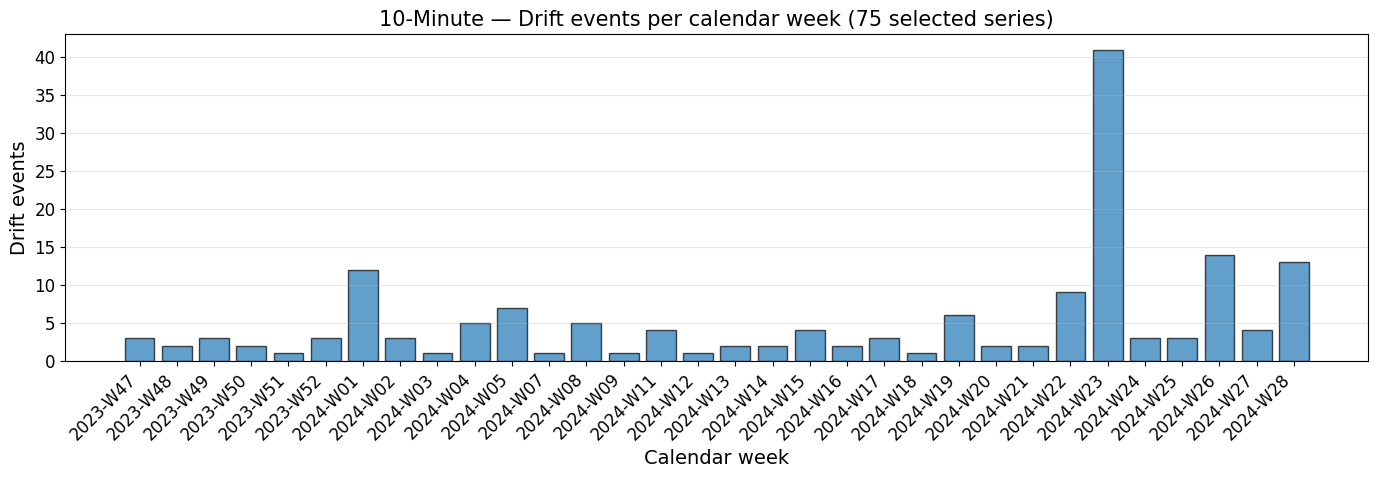


  Events per level:
    Institutions: 45 events across 18 distinct weeks
    Subnets: 50 events across 18 distinct weeks
    IPs: 70 events across 29 distinct weeks


In [32]:
events_10min = calendar_week_analysis(SOURCES, "10min",
                                      save_path=GRAPH_DIR / "DRIFT_calendar_weeks_10min.pdf")